# CE221 Nonlinear Structural Analysis

Instructor: Professor Khalid M. Mosalam<br>
Taisei Professor of Civil Engineering<br>
Director, Pacific Earthquake Engineering Research (PEER) Center<br>

Department of Civil and Environmental Engineering<br>
College of Engineering<br>
University of California, Berkeley<br>
Spring 2026

## Geometric Nonlinearity

In geometrically linear analysis, equilibrium is enforced in the *undeformed* configuration of the structure.
This approximation leads to simple linear equations, but the resulting solution is only an approximate equilibrium and does not strictly satisfy force balance in the deformed shape.
    
This simplification becomes inadequate when a structure is expected to undergo moderate to large displacements.
To account for geometric nonlinearity, two common approaches are used:

1. $P-\Delta$ analysis, in which large-displacement effects are incorporated into otherwise linearized equilibrium equations through additional geometric stiffness terms.
2. *Fully nonlinear analysis*, in which equilibrium is enforced directly in the deformed configuration of the structure. This approach will be investigated below using the [`Corotational02`](https://xara.so/user/manual/model/geomTransf/frame/Corotational02.html) formulation in [$\chi ara$](https://xara.so).

In general, a *fully nonlinear* analysis is more accurate because it enforces equilibrium consistently with the current geometry. However, the governing equations are significantly more complex, making hand calculations impractical and increasing the computational cost in finite element simulations.

By contrast, $P-\Delta$ analysis is an *approximate but efficient* technique that is reasonably accurate for problems involving moderate displacements. It leads to equations that are much easier to implement and solve. For this reason, $P-\Delta$ analysis became a standard tool well before the widespread availability of nonlinear finite element methods in the 1980s and continues to be used in engineering practice today, including in design code provisions.


### Software considerations

In nonlinear finite element analysis, equilibrium is typically solved using an iterative method (e.g., Newton-Raphson). In this context, the *tangent stiffness matrix* $K$ should represent the *gradient of the internal resisting forces with respect to the displacement field*, that is,

$$
\mathbf{K} \;\equiv\; \frac{\partial \mathbf{R}_{\text{int}}}{\partial \mathbf{u}},
$$

where $\mathbf{R}_{\text{int}}$ is the vector of internal resisting forces and $\mathbf{u}$ is the vector of nodal displacements.

When this gradient is computed *consistently* (as in a fully nonlinear formulation), the tangent stiffness correctly reflects how internal forces change with incremental deformation. This typically leads to *quadratic convergence* of Newton-type solvers and robust numerical performance.
    
In $P-\Delta$ analysis, however, the geometric stiffness contribution is introduced in an *approximate* manner. As a result, the tangent stiffness matrix is *not a true gradient* of the internal force vector. In numerical terms, the stiffness is said to be *inconsistent*, which can lead to slower convergence or a greater number of equilibrium iterations.

When both *geometric and material nonlinearities* are present, the computational cost of each iteration is often dominated by the material response (e.g., plasticity or damage). In such cases, a fully nonlinear formulation may actually converge more efficiently, and sometimes faster overall, than a $P-\Delta$ approximation, despite its greater theoretical complexity.

*Engineering takeaway*: $P-\Delta$ analysis trades mathematical consistency for simplicity and efficiency, while fully nonlinear formulations preserve consistency at the cost of more complex equations. Understanding this trade-off is essential when interpreting nonlinear analysis results.

## CE221 Notebook 1 — P-Delta Effects

This Jupyter notebook was prepared by Dr. Fan Hu under the guidance of Professor Khalid M. Mosalam. It builds upon earlier standalone Python scripts (`P-Delta-BVP.py` and `Cantilever-P-Delta-delta.py`) and significantly extends them into a unified, self-contained instructional notebook.

In this notebook, we study second-order (P–$\Delta$) effects using a simple cantilever beam example, progressing from a linear formulation to increasingly refined second-order models.

The original scripts have been reorganized, clarified, and enhanced to:
- explicitly contrast linear, fixed-$\Delta$ P–$\Delta$, and self-consistent P–$\Delta$ formulations;
- highlight the physical meaning of global ($\Delta$) and local ($\delta$) deformations;
- and connect analytical approximations to equilibrium concepts used in finite element analysis.

This notebook is intentionally implemented using basic Python tools (`numpy`, `scipy`, `matplotlib`) rather than `Xara`, so that the governing ideas can be clearly connected to hand calculations and underlying theory.

The **goal** is not to develop a general-purpose solver, but to provide a transparent and physically motivated introduction to second-order effects that prepares students for more advanced Xara-based analyses in later notebooks.


### Environment basics

In [326]:
import sys, platform, os
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Working directory:", os.getcwd())
print("Files here (first 10):", os.listdir(".")[:10])

Python: 3.11.14
Platform: Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
Working directory: /home/facundo/repositories/SEMM Fall 2025 Homework - Facundo Pfeffer/CE221_NonLinearStructuralAnalysis/ce211hw1
Files here (first 10): ['NB1_figure3.png', 'NB1_figure4.png', 'CE221_Notebook_1 - ORIGINAL.ipynb', 'CE221_Notebook_1_revised (3).ipynb', 'NB1_figure1.png', 'NB1_figure2.png']


### Import Python libraries

We will be using some common Python libraries to help with data processing. By convention, all libraries are imported at the top of the notebook.
It is also standard practice to use short aliases for convenience (e.g., `np` for `numpy`). Run the cell below to import the libraries required.

In [327]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp
import pandas as pd
from xara.units.si import N, m

### Problem description

We consider a vertical cantilever beam of length $L$, subjected to:
- a horizontal tip load $F$
- a constant axial compressive load $P$

The beam has constant flexural rigidity $EI$.

We will compare:
1. First-order (linear) bending response
2. Second-order response including P–$\Delta$ effects


### Model parameters

All parameters are chosen so the problem remains simple enough to be interpreted by hand.

<div style="border: 2px solid rgb(65, 96, 163); padding: 10px 14px; margin: 12px 0; border-radius: 8px; max-width: 100%; box-sizing: border-box;">
<strong>Modified:</strong> <em>Added units from xara.units.</em>
</div>

In [328]:
# Geometry and material
L = 6.0*m        # Length of cantilever (m)
EI = 1000.0 *10e3*N * m**2    # Flexural rigidity (kN·m^2)

# Loads
F = 10.0  *10e3*N      # Horizontal tip load (kN)
P = 50.0  *10e3*N      # Axial compressive load (kN)

### First-order (linear) beam model

We first consider the classical linear cantilever problem without second-order effects.

This solution will be used as a reference.

In [329]:
# Linear beam differential equation

def beam_eq_linear(x, y):
    v = y[0]                    # deflection
    dv = y[1]                   # slope
    d2v = (F * (L - x)) / EI    # curvature
    return np.vstack((dv, d2v))

### Including P-Delta effects

We now include the influence of the axial load $P$. The governing equation becomes nonlinear because the axial load acts through the lateral displacement.


#### Fixed $\Delta = \frac{F \cdot L^3}{3 EI}$

In [330]:
# Second-order beam equation (P–Delta)

def beam_eq_pdelta(x, y):
    v = y[0]       # deflection
    dv = y[1]      # slope

    x_max = L
    Delta = (F / (6 * EI)) * (3 * L * x_max**2 - x_max**3)

    d2v = (F * (L - x) + P * (Delta - v)) / EI
    return np.vstack((dv, d2v))

#### Self-consistent $\Delta^{(k+1)} = v^{(k)}(L)$

In [331]:
def make_beam_eq_pdelta_sc(Delta):
    def beam_eq(x, y):
        v = y[0]
        dv = y[1]
        d2v = (F * (L - x) + P * (Delta - v)) / EI
        return np.vstack((dv, d2v))
    return beam_eq


def solve_pdelta_sc(x, y_init, tol=1e-8, max_iter=100, verbose=False):

    # initial Delta guess: linear tip displacement
    Delta = (F * L**3) / (3 * EI)

    sol = None
    for k in range(max_iter):
        beam_eq_pdelta_sc = make_beam_eq_pdelta_sc(Delta)

        sol = solve_bvp(beam_eq_pdelta_sc, bc, x, y_init)

        if not sol.success:
            raise RuntimeError(f"solve_pdelta_sc failed at iter {k+1}: {sol.message}")

        Delta_new = sol.y[0, -1]  # v(L)

        if verbose:
            print(f"iter {k+1:02d}: Delta = {Delta:.6g} -> {Delta_new:.6g}, |Δ_new - Δ|={abs(Delta_new-Delta):.3e}")

        if abs(Delta_new - Delta) < tol:
            print(f"Converged in {k+1} iterations")
            return sol, Delta_new, k + 1

        # Update Delta and warm-start with current solution
        Delta = Delta_new
        y_init = sol.y  # warm start

    raise RuntimeError("Self-consistent Delta did not converge within max_iter.")

In [332]:
# Boundary conditions and solution (linear)

def bc(y0, yL):
    return np.array([y0[0], y0[1]])  # v(0)=0, slope(0)=0


# Initial guess for solution

x = np.linspace(0, L, 100)
y_init = np.zeros((2, x.size))  # Initial guess: zero deflection and slope


# Solve the linear BVP

sol_linear = solve_bvp(beam_eq_linear, bc, x, y_init)
sol_pdelta = solve_bvp(beam_eq_pdelta, bc, x, y_init)

print(f"Problem 2 of the homework: (F)(L**3)/(3EI) = {(F*L**3)/(3*EI)} m")
print(f"The solution with the linear ODE is: {sol_linear.y[0][-1]:.2f} m")

sol_pdelta_sc, Delta_sc, n_iter = solve_pdelta_sc(
    x, y_init.copy(), tol=1e-8, max_iter=100, verbose=False
)

Problem 2 of the homework: (F)(L**3)/(3EI) = 0.72 m
The solution with the linear ODE is: 0.72 m
Converged in 70 iterations


### Comparison of results

We now compare the linear and second-order deflections.

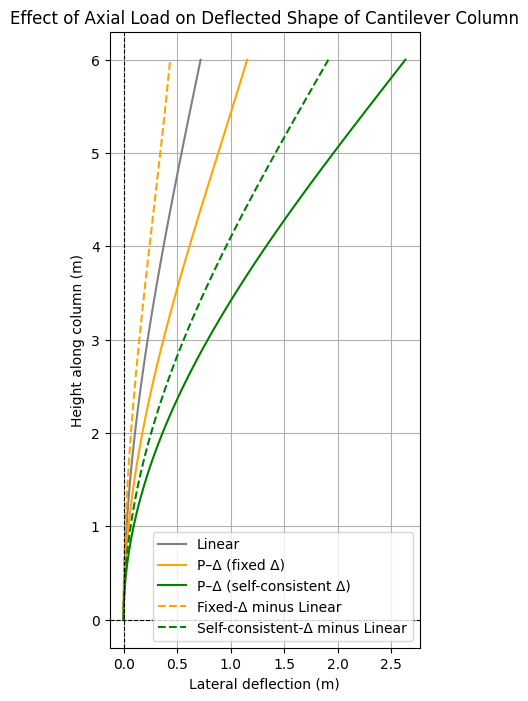

In [333]:
plt.figure(figsize=(4,8))
plt.plot(sol_linear.y[0], x, label="Linear", linestyle="-", color = "gray")
plt.plot(sol_pdelta.y[0], x, label="P–Δ (fixed Δ)", linestyle="-", color="orange")
plt.plot(sol_pdelta_sc.y[0], x, label="P–Δ (self-consistent Δ)", linestyle="-", color="green")

plt.plot(sol_pdelta.y[0] - sol_linear.y[0], x, label="Fixed-Δ minus Linear",  linestyle="--", color="orange")
plt.plot(sol_pdelta_sc.y[0] - sol_linear.y[0], x, label="Self-consistent-Δ minus Linear", linestyle="--", color="green")

plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")

plt.title("Effect of Axial Load on Deflected Shape of Cantilever Column")
plt.xlabel("Lateral deflection (m)")
plt.ylabel("Height along column (m)")

plt.legend()
plt.grid(True)
plt.savefig("NB1_figure1.png", dpi=300, bbox_inches="tight")
plt.show()

## Global (P–$\Delta$) and Local (P–$\delta$) Deformation: Conceptual Interpretation

In the previous section, we obtained the **total deflection** from the BVP solution and compared it to the **first-order (linear) deflection**. Here we add a *conceptual* interpretation that distinguishes between:

- **Global (P–$\Delta$) effect:** amplification of moments due to the *overall* lateral displacement (drift)
- **Local (P–$\delta$) effect:** additional moments due to the *difference* between the actual deflected shape and a straight chord connecting the end points (often associated with local curvature / imperfections)

For this simple cantilever under a tip load $F$, the first-order (Euler–Bernoulli) lateral displacement is

$$
\Delta(x) = \frac{F}{6EI}\left(3Lx^2 - x^3\right)
\tag{1}.
$$

We use this closed-form $\Delta(x)$ to visualize the decomposition into global and local components and to
plot the corresponding moment contributions.

**NOTE:** One can notice that the $\Delta(x)$ depends on $F$ only and does not involve the axial load $P$. In real applications, it should also be a function of P. Here, we use this elasitic solution without P-Delta effects for approximate conceptual illustration only to demonstrate the chord displacement and local deformation starting with some global displacement (which is approximate here as $\Delta(x)$, defined above in Equation (1)).

<div style="border: 2px solid rgb(65, 96, 163); padding: 10px 14px; margin: 12px 0; border-radius: 8px; max-width: 100%; box-sizing: border-box;">
<strong>Modified:</strong> <em>Added units from xara.units.</em>
</div>

In [334]:
# Parameters for the cantilever
L = 3.0 * m   # Length of the cantilever (m)
P = 1000.0 * N# Axial load (N)
F = 10.0 * N  # Lateral load at the free end (N)
E = 400e5 * N/(m**2)  # Young's modulus (Pa)
I = 1e-4 * m**4  # Moment of inertia (m^4)

# Discretize the cantilever for plotting
num_points = 100
x_c = np.linspace(0.0, L, num_points)

# First-order displacement shape (Euler–Bernoulli)
Delta_x = (F / (6.0 * E * I)) * (3.0 * L * x_c**2 - x_c**3)  # Lateral displacement along the cantilever
Delta_free_end = Delta_x[-1]  # Displacement at the free end

# Chord (linear) displacement connecting the end points
Delta_chord = (Delta_free_end / L) * x_c

# Local deformation (difference between chord and actual shape, P-delta effect)
delta_x = Delta_chord - Delta_x

# Moments due to P-Delta and P-delta effects
M_applied = F * (L - x_c)  # Applied moment due to F
M_global = P * (Delta_free_end - Delta_chord)  # Global moment due to P-Delta effect
M_local = P * delta_x  # Local moment due to P-delta effect

### Displacements: Approximate $\Delta(x)$, chord, and local deformation

- $\Delta(x)$ is the **first-order** displacement shape under $F$ only
- $\Delta_{\mathrm{chord}}(x)$ is the straight chord from $(0,0)$ to $(L,\Delta(L)$)
- $\delta(x) = \Delta_{\mathrm{chord}}(x) - \Delta(x)$ highlights the **local** deviation from the chord

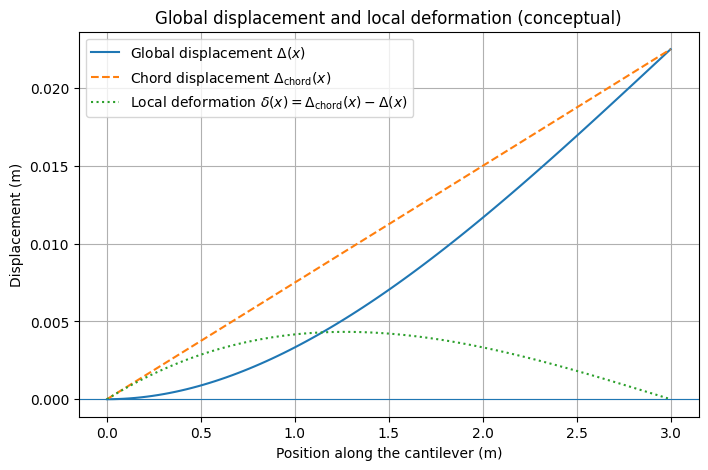

In [335]:
plt.figure(figsize=(8, 5))
plt.plot(x_c, Delta_x, label=r"Global displacement $\Delta(x)$")
plt.plot(x_c, Delta_chord, label=r"Chord displacement $\Delta_{\mathrm{chord}}(x)$", linestyle="--")
plt.plot(x_c, delta_x, label=r"Local deformation $\delta(x) = \Delta_{\mathrm{chord}}(x) - \Delta(x)$", linestyle=":")
plt.axhline(0.0, linewidth=0.8)
plt.title(r"Global displacement and local deformation (conceptual)")
plt.xlabel("Position along the cantilever (m)")
plt.ylabel("Displacement (m)")
plt.grid(True)
plt.legend()
plt.savefig("NB1_figure2.png", dpi=300, bbox_inches="tight")
plt.show()


### Moments: Applied $F(L-x)$, plus global $P$-$\Delta$, plus local $P$-$\delta$

We visualize how the bending moment diagram changes when we add:

1. The applied first-order moment $M_{\mathrm{applied}} = F(L-x)$
2. The **global** contribution $M_{\mathrm{global}} = P\,(\Delta(L)-\Delta_{\mathrm{chord}}(x))$
3. The **local** contribution $M_{\mathrm{local}} = P\,\delta(x)$


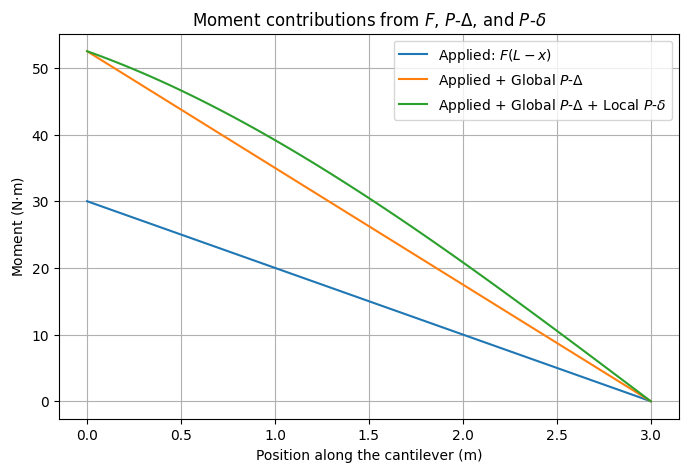

In [336]:
plt.figure(figsize=(8, 5))
plt.plot(x_c, M_applied, label=r"Applied: $F(L-x)$")
plt.plot(x_c, M_applied + M_global, label=r"Applied + Global $P$-$\Delta$")
plt.plot(x_c, M_applied + M_global + M_local, label=r"Applied + Global $P$-$\Delta$ + Local $P$-$\delta$")
plt.title(r"Moment contributions from $F$, $P$-$\Delta$, and $P$-$\delta$")
plt.xlabel("Position along the cantilever (m)")
plt.ylabel(r"Moment (N$\cdot$m)")
plt.grid(True)
plt.legend()
plt.savefig("NB1_figure3.png", dpi=300, bbox_inches="tight")
plt.show()


### Sketch: Undeformed vs. Deformed (amplified)

The deformed shape is amplified to make the geometry visible.


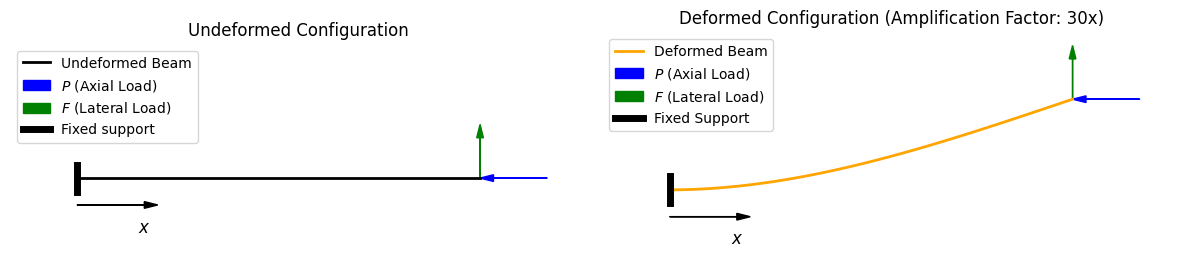

In [337]:
amplification_factor = 30

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Undeformed
axs[0].plot([0, L], [0, 0], color="black", linewidth=2, label="Undeformed Beam")
axs[0].arrow(L + 0.5, 0, -0.4, 0, head_width=0.05, head_length=0.1, fc="blue", ec="blue", label=r"$P$ (Axial Load)")
axs[0].arrow(L, 0, 0, 0.3, head_width=0.05, head_length=0.1, fc="green", ec="green", label=r"$F$ (Lateral Load)")
axs[0].arrow(0, -0.2, 0.5, 0, head_width=0.05, head_length=0.1, fc="black", ec="black") # x-axis arrow
axs[0].text(0.5, -0.3, "$x$", fontsize=12, color="black", ha="center", va="top") # Label for x-axis
axs[0].plot([0, 0], [-0.1, 0.1], color="black", linewidth=5, label="Fixed support")
axs[0].set_xlim([-0.5, L + 0.8])
axs[0].set_ylim([-0.5, 1])
axs[0].set_title("Undeformed Configuration")
axs[0].set_aspect("equal")
axs[0].axis("off")
axs[0].legend(loc="upper left")

# Deformed (using first-order shape for visualization)
axs[1].plot(x_c, amplification_factor * Delta_x, color="orange", linewidth=2, label="Deformed Beam")
axs[1].arrow(L + 0.5, amplification_factor * Delta_free_end, -0.4, 0, head_width=0.05, head_length=0.1, fc="blue", ec="blue", label=r"$P$ (Axial Load)")
axs[1].arrow(L, amplification_factor * Delta_free_end, 0, 0.3, head_width=0.05, head_length=0.1, fc="green", ec="green", label=r"$F$ (Lateral Load)")
axs[1].arrow(0, -0.2, 0.5, 0, head_width=0.05, head_length=0.1, fc="black", ec="black") # x-axis arrow
axs[1].text(0.5, -0.3, "$x$", fontsize=12, color="black", ha="center", va="top") # Label for x-axis
axs[1].plot([0, 0], [-0.1, 0.1], color="black", linewidth=5, label="Fixed Support")
axs[1].set_xlim([-0.5, L + 0.8])
axs[1].set_ylim([-0.5, amplification_factor * Delta_free_end + 0.5])
axs[1].set_title(f"Deformed Configuration (Amplification Factor: {amplification_factor}x)")
axs[1].set_aspect("equal")
axs[1].axis("off")
axs[1].legend(loc="upper left")

plt.tight_layout()
plt.savefig("NB1_figure4.png", dpi=300, bbox_inches="tight")
plt.show()

## Xara verification: geometric nonlinearity options

In this final section, we re-solve the same **cantilever column** problem in `Xara` and compare three geometric transformation choices:

- **Linear** (no second-order geometric stiffness)
- **PDelta** (second-order *global* P–$\Delta$ effect)
- [**Corotational02**](https://xara.so/user/manual/model/geomTransf/frame/Corotational02.html) (geometric nonlinearity via a corotational transformation)

The goal is *not* to reproduce the global/local decomposition in `Xara` (that is already shown above with our own code), but to confirm that `Xara`’s geometric-nonlinearity options produce the expected **overall amplification** for the same simple column problem.


In [338]:
try:
    import xara
    print("Xara imported successfully.")
except Exception as e:
    print(f"Xara not found. Installing...{e}")

Xara imported successfully.


In [339]:
def solve_cantilever_xara(L, EI, P, F, transf_type="Linear", n_ele=10, n_steps=20):
    """Return the tip lateral displacement (ux at the free end) for a cantilever column.

    Notes
    -----
    - We use an OpenSees-compatible PrismFrame element via Xara's compatibility layer.
    - To match the Euler-Bernoulli beam assumption in the handout, we choose E and Iz so that E*Iz = EI.
    - A is chosen large to minimize axial deformation effects (since the theory assumes inextensible column).
    """
    model = xara.Model(ndm=2, ndf=3)

    # Nodes
    node_tags = []
    for i in range(n_ele + 1):
        y = L * i / n_ele
        tag = i + 1
        node_tags.append(tag)
        model.node(tag, (0.0, y))

    # Fix base node (ux, uy, rz)
    model.fix(node_tags[0], (1, 1, 1))

    # Geometric transformation
    transf_tag = 1
    model.geomTransf(transf_type, transf_tag)

    # Section properties (E*Iz = EI)
    E = 1.0
    Iz = EI
    A = 1.0e6
    
    model.section("Elastic", 1, E=E, A=A, Iz=Iz)

    # Elements
    for e in range(n_ele):
        ele_tag = e + 1
        ni = node_tags[e]
        nj = node_tags[e + 1]
        model.element("PrismFrame", ele_tag, (ni, nj), section=1, transform=transf_tag)

    top = node_tags[-1]

    # Common analysis options
    model.system("BandGeneral")
    model.numberer("RCM")
    model.constraints("Plain")

    # --- Step 1: gravity (axial load) ---
    model.pattern("Plain", 1, "Linear")
    model.load(top, (0.0, -P, 0.0), pattern=1)  # (Fx, Fy, Mz)

    model.test("EnergyIncr", 1e-18, 10)
    model.algorithm("Newton")  # safer for PDelta/Coro compared to model.algorithm("Linear")
    model.integrator("LoadControl", 1.0)
    model.analysis("Static")

    ok = model.analyze(1)
    if ok != 0:
        raise RuntimeError(f"Axial-load step failed (transf={transf_type}, ok={ok}).")

    # Hold axial load as constant gravity
    model.loadConst(time=0.0)

    # --- Step 2: lateral load increments ---
    model.pattern("Plain", 2, "Linear")
    model.load(top, (F, 0.0, 0.0), pattern=2)

    # Re-set test/algorithm for lateral step
    model.test("EnergyIncr", 1e-18, 10)
    model.algorithm("Newton")

    d_lambda = 1.0 / n_steps
    model.integrator("LoadControl", d_lambda)

    for _ in range(n_steps):
        ok = model.analyze(1)
        if ok != 0:
            raise RuntimeError(f"Lateral-load step failed (transf={transf_type}, ok={ok}).")

    ux = model.nodeDisp(top, 1)  # dof=1 -> x tranf
    # uy = model.nodeDisp(top, 2)  # dof=2 -> y tranf
    # rz = model.nodeDisp(top, 3)  # dof=3 -> z tranf

    # --- Post-processing: internal axial force distribution (end of analysis) ---
    # Extract internal axial force for ALL elements (1 ... n_ele)
    # This is important for corotational formulation since axial force is NOT uniform.

    N_raw_list = []
    N_mag_list = []

    ele_tags = list(range(1, n_ele + 1))

    for ele in ele_tags:
        # For 2D PrismFrame elements:
        # localForce = [Fx_i, Fy_i, Mz_i, Fx_j, Fy_j, Mz_j] in the *local* system
        lf = model.eleResponse(ele, "localForce")

        # Axial force at the i-end (local x-axis, compression-positive)
        N_raw = lf[0]

        N_raw_list.append(N_raw)
        N_mag_list.append(abs(N_raw))

    # Convert to numpy arrays for convenience
    N_raw_arr = np.array(N_raw_list)
    N_mag_arr = np.array(N_mag_list)

    # Return full axial force distribution
    return ux, N_raw_arr, N_mag_arr


<div style="border: 2px solid rgb(65, 96, 163); padding: 10px 14px; margin: 12px 0; border-radius: 8px; max-width: 100%; box-sizing: border-box;">
<strong>Modified:</strong> <em>Added units from xara.units.</em>
</div>

In [340]:
# Geometry and material
L = 6.0*m      # Length of cantilever (m)
EI = 1000.0 *10e3*N*m**2    # Flexural rigidity (kN·m^2)

# Loads
F = 10.0 *10e3*N       # Horizontal tip load (kN)
P = 50 *10e3*N      # Axial compressive load (kN)

# Geometry and material
L = 6.0        # Length of cantilever (m)
EI = 1000.0    # Flexural rigidity (kN·m^2)

# Loads
F = 10.0       # Horizontal tip load (kN)
P = 50.0       # Axial compressive load (kN)



### Compare `Xara` results with the analytical BVP results

In [346]:
results_dict = {}    
n_ele_list = [2,5,10,20]
for n_ele in n_ele_list:
    # Run the three options
    transf_list = ["Linear", "PDelta", "Corotational02"]
    results = {}

    for transf in transf_list:
        ux, N_raw_arr, N_mag_arr = solve_cantilever_xara(
            L=L, EI=EI, P=P, F=F,
            n_ele=n_ele,  # This is the modified line.
            transf_type=transf)
        results[transf] = {"ux": ux, "N_raw": N_raw_arr, "N_mag": N_mag_arr}

    ux_linear, N_raw_linear, N_mag_linear = results["Linear"]["ux"], results["Linear"]["N_raw"], results["Linear"]["N_mag"]
    ux_pdelta, N_raw_pdelta, N_mag_pdelta = results["PDelta"]["ux"], results["PDelta"]["N_raw"], results["PDelta"]["N_mag"]
    ux_coro,   N_raw_coro,   N_mag_coro   = results["Corotational02"]["ux"], results["Corotational02"]["N_raw"], results["Corotational02"]["N_mag"]
    # Analytical tip deflections from our BVP solutions
    delta_linear_tip = sol_linear.y[0][-1]
    delta_pdelta_tip = sol_pdelta.y[0][-1]             # fixed-Δ
    delta_pdelta_sc_tip = sol_pdelta_sc.y[0][-1]       # self-consistent Δ

    print("="*100)
    print(f"Results for number of elements: {n_ele}")

    print("Tip lateral displacement (m)")
    print(f"Analytical (Linear)                     : {delta_linear_tip:.6g} m | Ratio /Δlin: {delta_linear_tip/delta_linear_tip:.6g}")
    print(f"Analytical (P–Delta, fixed Δ)           : {delta_pdelta_tip:.6g} m | Ratio /Δlin: {delta_pdelta_tip/delta_linear_tip:.6g}")
    print(f"Analytical (P–Delta, self-consistent Δ) : {delta_pdelta_sc_tip:.6g} m | Ratio /Δlin: {delta_pdelta_sc_tip/delta_linear_tip:.6g}")

    print()
    print(f"Xara (Linear transf)  : {ux_linear:.6g} m | Ratio /Δlin: {ux_linear/delta_linear_tip:.6g} ")
    print(f"Xara (PDelta transf)  : {ux_pdelta:.6g} m | Ratio /Δlin: {ux_pdelta/delta_linear_tip:.6g}")
    print(f"Xara (Corotational02) : {ux_coro:.6g} m | Ratio /Δlin: {ux_coro/delta_linear_tip:.6g}")

    print("\nAmplification ratios (relative to Linear)")
    print(f"Analytical fixed-Δ (P–Delta / Linear)           : {delta_pdelta_tip/delta_linear_tip:.6g}")
    print(f"Analytical self-consistent Δ (P–Delta / Linear) : {delta_pdelta_sc_tip/delta_linear_tip:.6g}")
    print(f"Xara PDelta (PDelta / Linear)                   : {ux_pdelta/ux_linear:.6g}")
    print(f"Xara Coro (Coro / Linear)                       : {ux_coro/ux_linear:.6g}")

    results_dict[n_ele] = {
        "BVPLinear": delta_linear_tip,
        "BVPPDelta": delta_pdelta_sc_tip,
        "XaraLinear": ux_linear,
        "XaraPDelta": ux_pdelta,
        "XaraCorotational": ux_coro,
    }


Results for number of elements: 2
Tip lateral displacement (m)
Analytical (Linear)                     : 0.72 m | Ratio /Δlin: 1
Analytical (P–Delta, fixed Δ)           : 1.15491 m | Ratio /Δlin: 1.60404
Analytical (P–Delta, self-consistent Δ) : 2.63458 m | Ratio /Δlin: 3.65914

Xara (Linear transf)  : 0.72 m | Ratio /Δlin: 1 
Xara (PDelta transf)  : 2.32484 m | Ratio /Δlin: 3.22894
Xara (Corotational02) : 1.94347 m | Ratio /Δlin: 2.69926

Amplification ratios (relative to Linear)
Analytical fixed-Δ (P–Delta / Linear)           : 1.60404
Analytical self-consistent Δ (P–Delta / Linear) : 3.65914
Xara PDelta (PDelta / Linear)                   : 3.22894
Xara Coro (Coro / Linear)                       : 2.69926
Results for number of elements: 5
Tip lateral displacement (m)
Analytical (Linear)                     : 0.72 m | Ratio /Δlin: 1
Analytical (P–Delta, fixed Δ)           : 1.15491 m | Ratio /Δlin: 1.60404
Analytical (P–Delta, self-consistent Δ) : 2.63458 m | Ratio /Δlin: 3.65914

Xa

### Stability sanity check (order-of-magnitude estimate)

To assess whether the magnitude of the second-order amplification is reasonable, we compare the applied axial load $P$ with an approximate Euler buckling load for a cantilever (fixed–free) column.

For a cantilever, the Euler buckling load can be estimated as

$$
P_{cr} \;\approx\; \frac{\pi^2 \, EI}{(K\,L)^2},
$$

where the effective length factor is $K = 2.0$ for a fixed–free column.

Near the buckling limit, classical second-order theory predicts that lateral displacements may be amplified by a factor on the order of $\frac{1}{1 - P/P_{cr}}.$

This simple estimate is used here as a **sanity check** to interpret the numerical results, rather than as an exact analytical solution.


In [ ]:
K = 2.0
Pcr = (np.pi**2 * EI) / ((K * L) ** 2)

ratio = P / Pcr
amp_est = 1.0 / (1.0 - ratio) if ratio < 1.0 else np.inf

print("Stability sanity check (order-of-magnitude) ")
print(f"Assumed effective length factor K     : {K}")
print(f"Approx. Euler buckling load Pcr       : {Pcr:.4g}")
print(f"Applied axial load P                  : {P:.4g}")
print(f"Load ratio P/Pcr                      : {ratio:.4g}")
print(f"Estimated amplification ~ 1/(1-P/Pcr) : {amp_est:.4g}")

Stability sanity check (order-of-magnitude) 
Assumed effective length factor K     : 2.0
Approx. Euler buckling load Pcr       : 68.54
Applied axial load P                  : -500
Load ratio P/Pcr                      : -7.295
Estimated amplification ~ 1/(1-P/Pcr) : 0.1206


### Why is the `Corotational02` response less conservative?

From the `Xara` verification results above, we observe that **`Corotational02` predicts a smaller lateral displacement** (i.e., a *stiffer* response and lower second-order amplification) than the `PDelta` transformation, even though the same nominal axial load $P$ is applied.

A key reason is that, in a corotational formulation, geometric nonlinearity enters through the geometric stiffness contribution $K_G$, which depends on the local internal axial force $N$. If the effective $N$ that develops along the member is **smaller** (especially near the free end), then the destabilizing geometric stiffness is reduced, leading to a stiffer overall response and hence a smaller displacement.

To examine this mechanism directly, we extract the **element-by-element axial force distribution** and plot the normalized ratio $N/P$ along the discretized cantilever (elements 1–20).


In [ ]:
n_ele = len(N_mag_linear)
ele_id = np.arange(1, n_ele + 1)

Pmag = abs(P)  # compare magnitudes

df_N = pd.DataFrame({
    "Element": ele_id,
    "Linear N/P": N_mag_linear / Pmag,
    "PDelta N/P": N_mag_pdelta / Pmag,
    "Corotational02 N/P": N_mag_coro / Pmag,
})

# Remove the Element column and transpose
df_N_T = df_N.drop(columns=["Element"]).T

# Rename columns to indicate element index clearly
df_N_T.columns = [f"Ele {i}" for i in ele_id]

# Display with desired precision
df_N_T_style = df_N_T.style.format("{:.4f}")

df_N_T_style


,Ele 1,Ele 2,Ele 3,Ele 4,Ele 5,Ele 6,Ele 7,Ele 8,Ele 9,Ele 10
Linear N/P,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
PDelta N/P,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
Corotational02 N/P,1.0001,1.0001,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002


In [ ]:
# --- Plot comparison of N/P along the member (element 1 -> n_ele) ---
plt.figure(figsize=(7,4))

plt.plot(df_N["Element"], df_N["PDelta N/P"], marker="o", color='orange', label="PDelta")
plt.plot(df_N["Element"], df_N["Corotational02 N/P"], marker="o", color='green', label="Corotational02")
plt.plot(df_N["Element"], df_N["Linear N/P"], marker="*", color='gray', label="Linear")


plt.xlabel(r"Element index (1 = base  $\rightarrow$  n = tip)")
plt.ylabel("Normalized axial force  |N| / |P|")
plt.title("Internal axial force distribution (normalized)")

plt.grid(True)
plt.legend()
plt.xticks(df_N["Element"], df_N["Element"].astype(int))
plt.savefig("NB1_figure5.png", dpi=300, bbox_inches="tight")
plt.show()


### Observations

The plot shows that the **axial force is not uniform** along the cantilever in the corotational formulation. In particular, the axial force magnitude near the **free end (tip)** can be significantly smaller than near the **fixed base**, while overall equilibrium is still satisfied. This is because the corotational analysis properly rotates the axial force to align with the deformed axis, whereas the $P-\Delta$ analysis assumes it is still aligned with the initial (undeformed) axis.

Because the corotational geometric stiffness contribution $K_G$ depends on the **local internal axial force $N$**, a smaller effective $N$ reduces the destabilizing geometric stiffness and leads to a **stiffer response and lower second-order amplification**. This explains why **[`Corotational02`](https://xara.so/user/manual/model/geomTransf/frame/Corotational02.html) predicts a smaller lateral displacement** than the `PDelta` transformation.

Therefore, the difference is not an error, but a consequence of how geometric nonlinearity is treated in the corotational formulation relative to the PDelta transformation.

$P-\Delta$ analysis is **more conservative** than corotational, but this conservatism arises primarily from the prediction of *bending moment demand*, not axial force.

Both methods predict the *same* peak axial force demand; however, the corotational analysis reveals that this peak occurs *only at the base* of the cantilever ($x=0$), where the deformed beam remains aligned with the applied axial load. As one moves along the deformed length of the beam, the member axis progressively rotates away from the axial load direction and towards the transverse load direction, which induces axial tension.

Because $P-\Delta$ analysis does not enforce equilibrium in the true (deformed) geomtry, it incorrectly predicts this peak axial force to persist olong the entire length of the beam. Such a distribution would only be physically consistent if the beam experienced no rotation or deformation.

When examining the bending moment distribution, $P-\Delta$ analysis is found to *overpredict* th emoment demand at the base ($x=0$).
This occurs because it fails to capture the geometric "stiffenning" effect that develops as the beam rotates and begins to partially balance the transverse load through axial tension. The Corotational formulation correctly captures this mechanism, leading to reduced displacement and, consequently, a more accurate prediction of bending moment demand.


## Interpretation

- The axial load amplifies lateral displacements.
- The difference increases as the axial load increases.
- This effect is captured by the $P-\Delta$ term.
- In addition, the local deviation of the deformed shape from the global chord, often referred to as the P–$\delta$ effect, helps explain the difference between the overall second-order response and the idealized global deformation.
- When the global displacement $\Delta$ is updated in a self-consistent manner (i.e., $\Delta = v(L)$), the analytical response becomes closer in spirit to the equilibrium solution obtained from finite element analysis.
- The corotational formulation predicts a smaller displacement (i.e., a stiffer response). This is because geometric nonlinearity enters through the local internal axial force, which is not uniform along the member. The reduced effective axial force contributing to the geometric stiffness leads to a smaller destabilizing effect and hence lower second-order amplification.

This notebook mirrors the assumptions made in the P–Delta handout and extends them by illustrating both a simplified (fixed-$\Delta$) and a refined (self-consistent $\Delta$) analytical treatment, while also clarifying how different finite element formulations represent geometric nonlinearity in distinct but physically consistent ways.


## Summary and next steps

In this notebook, you learned how second-order effects arise from simple equilibrium considerations and how different modeling assumptions influence the predicted response.

By comparing a linear solution, a simplified P–$\Delta$ formulation with fixed $\Delta$, and a refined self-consistent $\Delta$ formulation, you saw how analytical models can progressively approach the behavior captured by a finite element analysis using a *PDelta* transformation.

The *corotational* formulation, while also accounting for geometric nonlinearity, was shown to predict a less conservative (stiffer) response for this problem. This behavior is not an error, but a consequence of how geometric stiffness is constructed from the local internal axial force, which varies along the member. When the effective axial force contributing to geometric stiffness is reduced, the resulting second-order amplification is correspondingly smaller.

For larger systems and more complex geometries, specialized analysis tools such as `Xara` become essential. Later notebooks will return to Xara-based workflows, where geometric nonlinearity is handled implicitly through the formulation, and where careful interpretation of modeling assumptions remains critical.
